## 1. Import Library

Pada tahap pertama ini, dilakukan import seluruh library yang akan digunakan sepanjang proses pengerjaan. Library-library ini dipilih sesuai kebutuhan di setiap tahap, mulai dari membaca dan memproses gambar, mengekstrak fitur, hingga melatih dan mengevaluasi model klasifikasi. Berikut adalah penjelasan masing-masing library beserta fungsinya:

- **`os`** — digunakan untuk mengakses dan mengiterasi struktur folder dataset di sistem, sehingga setiap subfolder kelas bisa dibaca secara otomatis tanpa perlu menuliskan path satu per satu.
- **`cv2` (OpenCV)** — library utama untuk pengolahan gambar, digunakan mulai dari membaca file gambar dengan `cv.imread()`, mengonversi ke grayscale dengan `cv.cvtColor()`, menyeragamkan ukuran dengan `cv.resize()`, hingga melakukan augmentasi berupa flip horizontal, flip vertikal, dan rotasi 90 derajat.
- **`numpy`** — digunakan secara intensif untuk operasi array pada data gambar, termasuk membuat kernel Gaussian secara manual, operasi padding, konvolusi, serta menyimpan seluruh data gambar dalam bentuk array multidimensi.
- **`pandas`** — digunakan untuk menyusun hasil ekstraksi fitur ke dalam bentuk DataFrame, menyimpannya ke file CSV, dan membacanya kembali untuk keperluan seleksi fitur dan pemodelan.
- **`matplotlib`** — digunakan untuk menampilkan sampel gambar dari setiap kelas, membandingkan hasil preprocessing sebelum dan sesudah, serta memvisualisasikan grafik akurasi dan metrik evaluasi lainnya.
- **`seaborn`** — digunakan khusus untuk membuat heatmap korelasi antar fitur setelah proses feature selection, sehingga bisa dilihat secara visual apakah masih ada fitur yang terlalu berkorelasi satu sama lain.
- **`graycomatrix`, `graycoprops` (skimage)** — digunakan untuk menghitung matriks GLCM dari gambar hasil preprocessing pada empat arah sudut, sekaligus mengekstrak fitur-fitur teksturnya seperti contrast, homogeneity, dissimilarity, ASM, energy, dan correlation.
- **`entropy` (scipy.stats)** — digunakan untuk menghitung nilai entropy dari matriks GLCM sebagai salah satu fitur tambahan yang merepresentasikan tingkat keacakan atau kompleksitas tekstur gambar.
- **`convolve` (scipy.ndimage)** — digunakan sebagai dasar operasi konvolusi 1 dimensi dalam implementasi Haar Wavelet manual, diterapkan pada baris dan kolom gambar untuk menghasilkan sub-band frekuensi LL, LH, HL, dan HH.
- **`RandomForestClassifier`** — model ensemble berbasis pohon keputusan yang akan dilatih dengan 100 estimator untuk mengklasifikasikan jenis penyakit daun padi.
- **`SVC`** — model Support Vector Machine dengan kernel RBF yang bekerja dengan mencari hyperplane terbaik untuk memisahkan antar kelas di ruang fitur berdimensi tinggi.
- **`KNeighborsClassifier`** — model KNN yang mengklasifikasikan data baru berdasarkan mayoritas label dari 5 tetangga terdekatnya di ruang fitur.
- **`sklearn.metrics`** — menyediakan seluruh fungsi evaluasi yang dibutuhkan, termasuk `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `classification_report`, dan `ConfusionMatrixDisplay` untuk menampilkan confusion matrix secara visual.

In [131]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from scipy.ndimage import convolve  # Digunakan untuk Haar Wavelet manual
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

## 2. Data Loading



In [132]:
DATASET_PATH = "dataset"
TARGET_SIZE  = (512, 512)
KELAS_VALID  = ['blast', 'blight', 'tungro']

data      = []
labels    = []
file_name = []

for sub_folder in sorted(os.listdir(DATASET_PATH)):
    sub_folder_path = os.path.join(DATASET_PATH, sub_folder)

    if not os.path.isdir(sub_folder_path):
        continue
    if sub_folder not in KELAS_VALID:
        print(f"⚠️  Folder '{sub_folder}' dilewati (bukan kelas dataset)")
        continue

    sub_folder_files = os.listdir(sub_folder_path)
    print(f"📂 Memuat kelas '{sub_folder}': {len(sub_folder_files)} file...")

    for filename in sub_folder_files:
        img_path = os.path.join(sub_folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            print(f"   ⚠️  Gagal membaca: {filename}")
            continue
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = cv.resize(img, TARGET_SIZE, interpolation=cv.INTER_AREA)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data      = np.array(data, dtype=np.uint8)
labels    = np.array(labels)

print()
print(f"✅ Total gambar berhasil dimuat: {len(data)}")
print(f"   Ukuran gambar : {data[0].shape}")
print(f"   Tipe data     : {data.dtype}")
print(f"📊 Distribusi per kelas:")
for kelas in KELAS_VALID:
    jumlah = np.sum(labels == kelas)
    print(f"   {kelas:10s}: {jumlah} gambar")

📂 Memuat kelas 'blast': 80 file...
📂 Memuat kelas 'blight': 80 file...
📂 Memuat kelas 'tungro': 80 file...

✅ Total gambar berhasil dimuat: 240
   Ukuran gambar : (512, 512)
   Tipe data     : uint8
📊 Distribusi per kelas:
   blast     : 80 gambar
   blight    : 80 gambar
   tungro    : 80 gambar


## Visualisasi Sampel Dataset


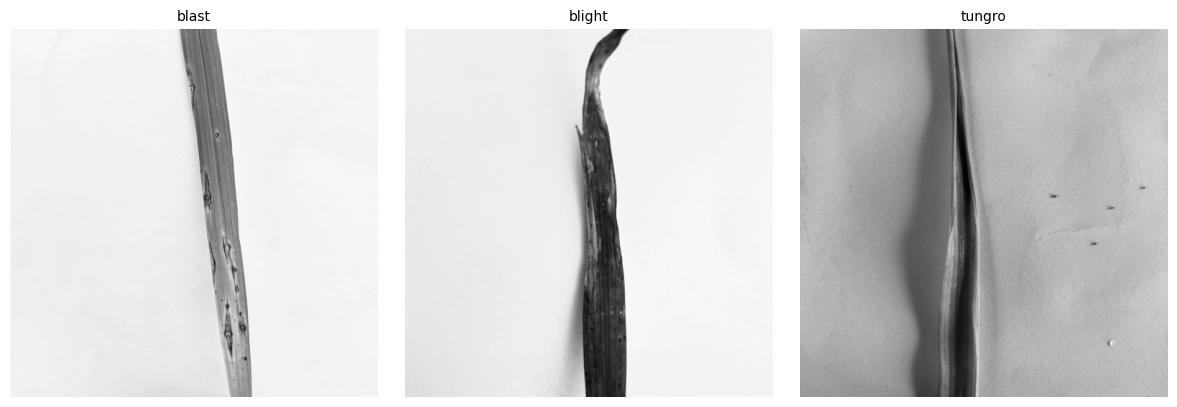

In [133]:
unique_labels = np.unique(labels)
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))

for ax, kelas in zip(axes, unique_labels):
    idx = np.where(labels == kelas)[0][0]
    ax.imshow(data[idx], cmap='gray')
    ax.set_title(kelas, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Data Augmentation


In [134]:
data_augmented      = list(data)
labels_augmented    = list(labels)
file_name_augmented = list(file_name)

for i in range(len(data)):
    img   = data[i]
    label = labels[i]
    fname = file_name[i]
    name, ext = os.path.splitext(fname)

    # Flip Horizontal
    flipped_h = cv.flip(img, 1)
    data_augmented.append(flipped_h)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_flipH{ext}")

    # Flip Vertikal
    flipped_v = cv.flip(img, 0)
    data_augmented.append(flipped_v)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_flipV{ext}")

    # Rotasi 90°
    rotated = cv.rotate(img, cv.ROTATE_90_CLOCKWISE)
    data_augmented.append(rotated)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_rot90{ext}")

data_augmented      = np.array(data_augmented, dtype=object)
labels_augmented    = np.array(labels_augmented)
file_name_augmented = np.array(file_name_augmented)

print(f"Data sebelum augmentasi : {len(data)}")
print(f"Data setelah augmentasi : {len(data_augmented)}")

Data sebelum augmentasi : 240
Data setelah augmentasi : 960


## 4. Preprocessing — Percobaan 3

In [135]:
def resize(image, target_size=(512, 512)):
    return cv.resize(image, target_size, interpolation=cv.INTER_AREA)

def normalisasi(image):
    return image.astype(np.float32) / 255.0

def gaussianKernel(ksize=5, sigma=1.0):
    if ksize % 2 == 0:
        raise ValueError("Ukuran kernel harus ganjil, misalnya 3, 5, atau 7.")

    if sigma <= 0:
        raise ValueError("Nilai sigma harus lebih besar dari 0.")

    tengah = ksize // 2
    kernel = np.zeros((ksize, ksize), dtype=np.float32)

    for y in range(-tengah, tengah + 1):
        for x in range(-tengah, tengah + 1):
            nilai = np.exp(-(x**2 + y**2) / (2 * sigma**2))
            kernel[y + tengah, x + tengah] = nilai

    kernel = kernel / np.sum(kernel)
    return kernel

def konvolusi(image, kernel):
    image = image.astype(np.float32)
    tinggi, lebar = image.shape

    k_tinggi, k_lebar = kernel.shape
    pad_y = k_tinggi // 2
    pad_x = k_lebar // 2

    padded = np.pad(image, ((pad_y, pad_y), (pad_x, pad_x)), mode='edge')
    hasil = np.zeros((tinggi, lebar), dtype=np.float32)

    for y in range(tinggi):
        for x in range(lebar):
            area = padded[y:y + k_tinggi, x:x + k_lebar]
            hasil[y, x] = np.sum(area * kernel)

    hasil = np.clip(hasil, 0, 255).astype(np.uint8)
    return hasil

def gaussianBlur(image, ksize=3, sigma=0.5):
    kernel = gaussianKernel(ksize=ksize, sigma=sigma)
    hasil = konvolusi(image, kernel)
    return hasil

def prepro3(image, target_size=(512, 512)):
    img = image.astype(np.uint8)
    img = resize(img, target_size)
    img = gaussianBlur(img, ksize=3, sigma=0.5)
    img = normalisasi(img)
    img_uint8 = (img * 255).astype(np.uint8)
    return img_uint8

In [136]:
dataPreprocessed = []

for i in range(len(data_augmented)):
    img_prep = prepro3(data_augmented[i], TARGET_SIZE)
    dataPreprocessed.append(img_prep)

dataPreprocessed = np.array(dataPreprocessed)

print(f"   Preprocessing selesai!")
print(f"   Jumlah gambar    : {len(dataPreprocessed)}")
print(f"   Ukuran gambar    : {dataPreprocessed[0].shape}")
print(f"   Tipe data        : {dataPreprocessed[0].dtype}")
print(f"   Nilai min / max  : {dataPreprocessed[0].min()} / {dataPreprocessed[0].max()}")

   Preprocessing selesai!
   Jumlah gambar    : 960
   Ukuran gambar    : (512, 512)
   Tipe data        : uint8
   Nilai min / max  : 68 / 243


## Visualisasi Hasil Preprocessing

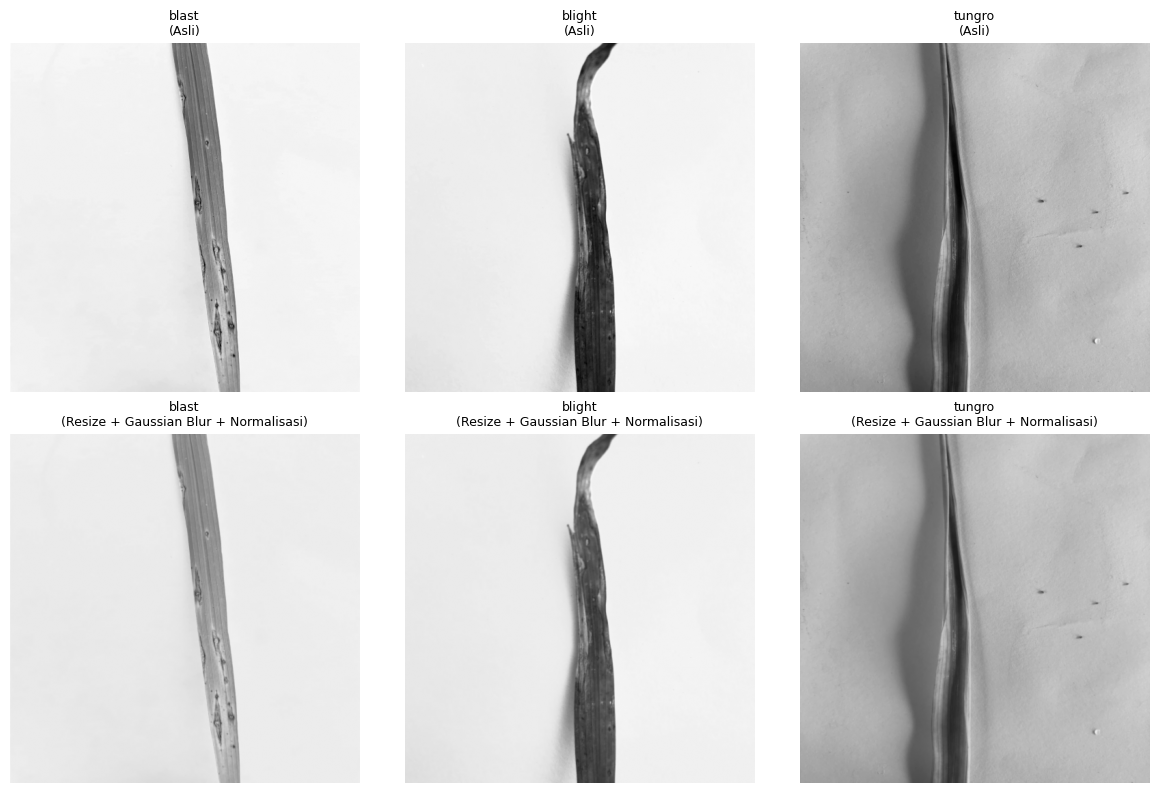

In [137]:
unique_labels = np.unique(labels_augmented)
n_kelas = len(unique_labels)

fig, axes = plt.subplots(2, n_kelas, figsize=(4 * n_kelas, 8))

for col, kelas in enumerate(unique_labels):
    idx = np.where(labels_augmented == kelas)[0][0]

    # Baris 1: gambar asli
    axes[0, col].imshow(data_augmented[idx].astype(np.uint8), cmap='gray')
    axes[0, col].set_title(f"{kelas}\n(Asli)", fontsize=9)
    axes[0, col].axis('off')

    # Baris 2: hasil preprocessing
    axes[1, col].imshow(dataPreprocessed[idx], cmap='gray', vmin=0, vmax=255)
    axes[1, col].set_title(f"{kelas}\n(Resize + Gaussian Blur + Normalisasi)", fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

## 5. Ekstraksi Fitur GLCM

Pada tahap ini, fitur tekstur diekstrak dari setiap gambar menggunakan metode Gray Level Co-occurrence Matrix (GLCM). GLCM bekerja dengan menghitung seberapa sering dua piksel dengan nilai intensitas tertentu muncul berdampingan pada suatu arah dan jarak tertentu. Untuk mendapatkan representasi tekstur yang lebih menyeluruh, perhitungan dilakukan pada empat arah sudut sekaligus yaitu 0°, 45°, 90°, dan 135°. Setiap sudut dikonversi ke satuan radian sebelum dimasukkan ke fungsi `graycomatrix()`. Jika sudut yang dimasukkan tidak termasuk salah satu dari keempat pilihan tersebut, fungsi akan melempar error secara eksplisit.

Fungsi `glcm()` menghitung matriks GLCM menggunakan `graycomatrix()` dengan konfigurasi berikut:

- **`distances=[1]`** — jarak antar piksel yang dibandingkan adalah 1 piksel, artinya hanya piksel yang langsung bertetangga yang diperhitungkan.
- **`levels=256`** — jumlah tingkat keabuan yang digunakan sesuai dengan rentang nilai piksel 0–255.
- **`symmetric=True`** — matriks dibuat simetris sehingga pasangan piksel (i,j) dan (j,i) dihitung secara bersamaan.
- **`normed=True`** — nilai matriks dinormalisasi menjadi probabilitas sehingga totalnya berjumlah 1.

Dari setiap matriks GLCM yang dihasilkan, diekstrak tujuh fitur tekstur menggunakan fungsi-fungsi berikut:

- **`contrast()`** — mengukur seberapa besar perbedaan intensitas antara piksel yang berdampingan. Nilai tinggi menandakan tekstur yang kasar dengan variasi intensitas besar.
- **`homogenity()`** — mengukur keseragaman distribusi elemen dalam matriks GLCM. Nilai tinggi menandakan tekstur yang halus dan seragam.
- **`dissimilarity()`** — mirip dengan contrast namun menggunakan skala linear, sehingga lebih sensitif terhadap perbedaan intensitas kecil.
- **`ASM()`** — Angular Second Moment, mengukur keseragaman tekstur secara keseluruhan. Nilai tinggi menandakan pola yang sangat teratur dan berulang.
- **`energy()`** — merupakan akar kuadrat dari ASM, memberikan representasi yang lebih intuitif dari keseragaman tekstur.
- **`correlation()`** — mengukur hubungan linier antara pasangan piksel dalam matriks GLCM. Nilai mendekati 1 atau -1 menandakan pola yang sangat terstruktur.
- **`entropyGlcm()`** — mengukur tingkat keacakan atau kompleksitas distribusi nilai dalam matriks GLCM. Nilai tinggi menandakan tekstur yang kompleks dan tidak beraturan.

Setelah seluruh fungsi didefinisikan, proses ekstraksi dijalankan dalam dua tahap. Tahap pertama, matriks GLCM dihitung untuk setiap gambar pada keempat sudut secara bersamaan dalam satu loop. Hasilnya disimpan ke dalam empat list terpisah yaitu `Derajat0`, `Derajat45`, `Derajat90`, dan `Derajat135`, masing-masing menyimpan matriks GLCM untuk sudut yang sesuai. Proses ini dijalankan terhadap seluruh 960 gambar dari `dataPreprocessed` dengan progress yang ditampilkan setiap 100 gambar.

Tahap kedua, dari matriks GLCM yang sudah tersimpan, diekstrak ketujuh nilai fitur untuk setiap sudut menggunakan loop terpisah. Setiap fitur pada setiap sudut disimpan ke dalam list tersendiri, misalnya `Kontras0` untuk nilai contrast pada sudut 0°, `homogenity45` untuk homogeneity pada sudut 45°, dan seterusnya. Pendekatan ini menghasilkan total 28 list fitur yang masing-masing berisi 960 nilai, satu nilai per gambar. Seluruh list fitur ini nantinya akan digabungkan bersama fitur Wavelet ke dalam satu DataFrame pada tahap penyimpanan CSV.

In [138]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan: 0, 45, 90, atau 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [139]:
Derajat0   = []
Derajat45  = []
Derajat90  = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(dataPreprocessed)}")

   Progress: 100/960
   Progress: 200/960
   Progress: 300/960
   Progress: 400/960
   Progress: 500/960
   Progress: 600/960
   Progress: 700/960
   Progress: 800/960
   Progress: 900/960


In [140]:
Kontras0, Kontras45, Kontras90, Kontras135                     = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135          = [], [], [], []
entropy0, entropy45, entropy90, entropy135                      = [], [], [], []
ASM0, ASM45, ASM90, ASM135                                      = [], [], [], []
energy0, energy45, energy90, energy135                          = [], [], [], []
correlation0, correlation45, correlation90, correlation135      = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

## 6. Ekstraksi Fitur Wavelet (Haar — Implementasi Manual)

Selain fitur GLCM, diekstrak juga fitur frekuensi gambar menggunakan Haar Wavelet yang diimplementasikan secara manual tanpa menggunakan library pywt. Haar Wavelet bekerja dengan memdekomposisi gambar ke dalam komponen frekuensi rendah dan frekuensi tinggi secara bertingkat, sehingga bisa menangkap informasi tekstur pada berbagai skala sekaligus. Sebelum fungsi didefinisikan, terlebih dahulu dibuat dua filter dasar Haar yaitu:

- **`HAAR_LP = [1/√2, 1/√2]`** — filter low-pass yang menangkap komponen frekuensi rendah (aproksimasi/rata-rata).
- **`HAAR_HP = [1/√2, -1/√2]`** — filter high-pass yang menangkap komponen frekuensi tinggi (detail/perubahan).

Fungsi `haar_dwt2d_level1()` menerapkan kedua filter tersebut secara berurutan pada dimensi baris dan kolom gambar menggunakan `convolve1d()` dari `scipy.ndimage` dengan mode `wrap`. Proses ini menghasilkan empat sub-band sekaligus:

- **`LL`** — hasil filter low-pass pada baris dan kolom, merepresentasikan aproksimasi keseluruhan gambar dalam resolusi lebih kecil.
- **`LH`** — hasil filter low-pass pada baris dan high-pass pada kolom, menangkap detail perubahan arah horizontal.
- **`HL`** — hasil filter high-pass pada baris dan low-pass pada kolom, menangkap detail perubahan arah vertikal.
- **`HH`** — hasil filter high-pass pada baris dan kolom, menangkap detail perubahan arah diagonal.

Setiap sub-band kemudian di-downsample dengan mengambil setiap piksel kedua (`[::2]`) pada baris maupun kolom, sehingga ukurannya menjadi setengah dari gambar input.

Fungsi `ekstraksi_wavelet()` menjalankan dekomposisi sebanyak dua level secara berulang. Pada setiap level, sub-band LL digunakan sebagai input untuk level berikutnya sehingga dekomposisi bersifat bertingkat. Dari setiap sub-band detail (LH, HL, HH) di kedua level, diekstrak dua nilai statistik yaitu mean dan standar deviasi. Khusus untuk sub-band LL, nilai mean dan standar deviasinya hanya diambil pada level terakhir karena LL di level terakhir merepresentasikan aproksimasi paling halus dari gambar. Total fitur yang dihasilkan per gambar adalah **14 fitur**, dengan rincian 2 fitur dari LL level 2, dan masing-masing 6 fitur dari sub-band detail di setiap level. Seluruh fitur ini nantinya akan digabungkan bersama fitur GLCM ke dalam satu DataFrame pada tahap penyimpanan CSV.

In [141]:
HAAR_LP = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
HAAR_HP = np.array([1/np.sqrt(2), -1/np.sqrt(2)])

def haar_dwt2d_level1(image):
    img = image.astype(np.float32)

    from scipy.ndimage import convolve1d
    L_row = convolve1d(img,    HAAR_LP, axis=1, mode='wrap')[:, ::2]
    H_row = convolve1d(img,    HAAR_HP, axis=1, mode='wrap')[:, ::2]

    LL = convolve1d(L_row, HAAR_LP, axis=0, mode='wrap')[::2, :]
    LH = convolve1d(L_row, HAAR_HP, axis=0, mode='wrap')[::2, :]
    HL = convolve1d(H_row, HAAR_LP, axis=0, mode='wrap')[::2, :]
    HH = convolve1d(H_row, HAAR_HP, axis=0, mode='wrap')[::2, :]

    return LL, LH, HL, HH


def ekstraksi_wavelet(image, level=2):
    fitur = []
    current = image.astype(np.float32)

    for lv in range(1, level + 1):
        LL, LH, HL, HH = haar_dwt2d_level1(current)

        if lv == level:
            fitur.append(np.mean(LL))
            fitur.append(np.std(LL))

        # Detail sub-bands setiap level
        fitur.append(np.mean(LH));  fitur.append(np.std(LH))
        fitur.append(np.mean(HL));  fitur.append(np.std(HL))
        fitur.append(np.mean(HH));  fitur.append(np.std(HH))

        # LL menjadi input level berikutnya
        current = LL

    return fitur

## 7. Simpan Hasil Ekstraksi ke CSV

Pada tahap ini, seluruh fitur yang telah diekstrak dari GLCM dan Wavelet digabungkan dan disimpan ke dalam satu file CSV. Proses dimulai dengan menjalankan fungsi `ekstraksi_wavelet()` terhadap seluruh 960 gambar dari `dataPreprocessed` menggunakan loop, dengan progress yang ditampilkan setiap 100 gambar. Hasil ekstraksi setiap gambar berupa list 14 nilai fitur, yang kemudian dikumpulkan ke dalam list `wavelet_features` dan dikonversi menjadi numpy array berukuran 960 × 14.

Setelah semua fitur tersedia, dibuat sebuah dictionary `dataTable` yang menggabungkan seluruh informasi dan fitur ke dalam satu struktur, yaitu:

- **`Filename` dan `Label`** — informasi nama file dan kelas dari setiap gambar yang diambil dari `file_name_augmented` dan `labels_augmented`.
- **28 fitur GLCM** — seluruh list fitur hasil ekstraksi GLCM pada keempat sudut, mencakup Contrast, Homogeneity, Dissimilarity, Entropy, ASM, Energy, dan Correlation masing-masing untuk sudut 0°, 45°, 90°, dan 135°.
- **14 fitur Wavelet** — diambil kolom per kolom dari array `wavelet_features` menggunakan `enumerate(wav_col_names)`, dengan nama kolom yang sudah didefinisikan secara eksplisit seperti `Wav_LL_mean`, `Wav_LH_L2_std`, `Wav_HH_L1_mean`, dan seterusnya agar mudah diidentifikasi pada tahap selanjutnya.

Dictionary tersebut kemudian dikonversi menjadi DataFrame menggunakan `pandas` dan disimpan ke file `hasil_ekstraksi_percobaan3.csv` menggunakan `df.to_csv()`. File CSV ini lalu dibaca kembali menggunakan `pd.read_csv()` untuk memverifikasi bahwa penyimpanan berjalan dengan benar. Hasilnya berupa DataFrame berukuran 960 baris dan 44 kolom, terdiri dari 2 kolom informasi, 28 fitur GLCM, dan 14 fitur Wavelet. File CSV inilah yang menjadi sumber data utama untuk tahap feature selection dan pemodelan selanjutnya.

In [142]:
wavelet_features = []
for i in range(len(dataPreprocessed)):
    wav_feat = ekstraksi_wavelet(dataPreprocessed[i], level=2)
    wavelet_features.append(wav_feat)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(dataPreprocessed)}")

wavelet_features = np.array(wavelet_features)

n_wav = wavelet_features.shape[1]
wav_col_names = (
    ['Wav_LL_mean', 'Wav_LL_std'] +
    ['Wav_LH_L2_mean', 'Wav_LH_L2_std',
     'Wav_HL_L2_mean', 'Wav_HL_L2_std',
     'Wav_HH_L2_mean', 'Wav_HH_L2_std'] +
    ['Wav_LH_L1_mean', 'Wav_LH_L1_std',
     'Wav_HL_L1_mean', 'Wav_HL_L1_std',
     'Wav_HH_L1_mean', 'Wav_HH_L1_std']
)

# Buat dictionary semua fitur
dataTable = {
    'Filename' : file_name_augmented,
    'Label'    : labels_augmented,
    # GLCM Features
    'Contrast0': Kontras0,     'Contrast45': Kontras45,     'Contrast90': Kontras90,     'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0,      'Entropy45': entropy45,      'Entropy90': entropy90,      'Entropy135': entropy135,
    'ASM0': ASM0,              'ASM45': ASM45,              'ASM90': ASM90,              'ASM135': ASM135,
    'Energy0': energy0,        'Energy45': energy45,        'Energy90': energy90,        'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

# Tambahkan fitur Wavelet
for j, col in enumerate(wav_col_names):
    dataTable[col] = wavelet_features[:, j]

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan3.csv')
print(f"   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan3.csv'")
print(f"   Shape DataFrame: {hasilEkstrak.shape}")
hasilEkstrak.head()

   Progress: 100/960
   Progress: 200/960
   Progress: 300/960
   Progress: 400/960
   Progress: 500/960
   Progress: 600/960
   Progress: 700/960
   Progress: 800/960
   Progress: 900/960
   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan3.csv'
   Shape DataFrame: (960, 44)


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Wav_HL_L2_mean,Wav_HL_L2_std,Wav_HH_L2_mean,Wav_HH_L2_std,Wav_LH_L1_mean,Wav_LH_L1_std,Wav_HL_L1_mean,Wav_HL_L1_std,Wav_HH_L1_mean,Wav_HH_L1_std
0,IMG_0448.jpg,blast,22.007453,19.451905,2.078026,26.796926,0.871211,0.848068,0.901274,0.845056,...,-0.001106,0.704151,909.62335,92.96109,-0.011673,3.314904,-0.046677,13.306694,-0.000473,2.333170
1,IMG_0535.jpg,blast,18.272639,19.775403,0.896110,18.059191,0.889952,0.857992,0.913032,0.860759,...,0.000038,0.378841,864.87445,149.48810,-0.346329,2.619860,0.147598,14.860502,-0.000046,1.410880
2,IMG_0536.jpg,blast,32.911792,36.557761,3.070970,33.144113,0.719761,0.672854,0.782717,0.676526,...,0.000557,0.751313,667.30170,162.31680,-0.458176,4.036119,-0.199234,18.028477,0.000809,2.787984
3,IMG_0541.jpg,blast,19.208128,24.729957,3.543806,18.790779,0.727720,0.663210,0.744754,0.658314,...,-0.000008,0.714462,645.42910,156.79701,-0.390366,4.776781,0.144852,14.191468,-0.002792,2.646962
4,IMG_0543.jpg,blast,18.660290,20.396590,2.204222,20.113821,0.726115,0.673187,0.777902,0.663166,...,0.000290,0.545758,654.30460,148.47047,-0.093536,3.749378,-0.190765,14.307577,0.000397,2.042922


## 8. Feature Selection (Korelasi)

Dari 42 fitur numerik yang tersedia, tidak semuanya memberikan informasi yang unik dan berguna bagi model. Beberapa fitur bisa jadi sangat mirip satu sama lain karena mengukur hal yang hampir sama, sehingga keberadaannya justru bisa membuat model lebih lambat dan berpotensi overfit. Untuk mengatasi hal ini, dilakukan seleksi fitur berbasis korelasi dengan tujuan membuang fitur-fitur yang terlalu redundan.

Proses seleksi dimulai dengan menghitung matriks korelasi antar seluruh 42 fitur numerik menggunakan `.corr()`, dengan kolom `Label` dan `Filename` dikeluarkan terlebih dahulu karena bukan fitur numerik. Kemudian dibuat array boolean `columns` berukuran 42 elemen yang awalnya seluruhnya bernilai `True`, yang berfungsi sebagai penanda fitur mana yang akan dipertahankan. Pemeriksaan dilakukan menggunakan dua loop bersarang untuk memeriksa setiap pasang fitur:

- Jika nilai korelasi absolut antara fitur ke-`i` dan fitur ke-`j` mencapai atau melebihi threshold **0.95**, artinya kedua fitur tersebut hampir identik secara statistik.
- Dalam kondisi tersebut, fitur ke-`j` ditandai sebagai `False` dan akan dibuang, sementara fitur ke-`i` yang lebih awal dipertahankan.
- Pengecekan `if columns[j]` memastikan fitur yang sudah ditandai untuk dibuang tidak diperiksa ulang, sehingga tidak terjadi penghapusan ganda.

Setelah seluruh pasang fitur diperiksa, fitur-fitur yang masih bertanda `True` dikumpulkan ke dalam variabel `select` dan digunakan untuk membuat DataFrame baru `x_new` yang hanya berisi fitur-fitur terpilih. Label kelas disimpan terpisah ke dalam variabel `y`. Dari proses ini, jumlah fitur berhasil dikurangi dari **42 menjadi 26 fitur**, yang berarti terdapat 16 fitur redundan yang berhasil diidentifikasi dan dibuang.

Untuk memverifikasi hasil seleksi secara visual, dibuat heatmap korelasi dari 26 fitur terpilih menggunakan `sns.heatmap()` dengan anotasi nilai korelasi pada setiap sel. Ukuran figure disesuaikan secara dinamis menggunakan `max(12, x_new.shape[1])` agar heatmap tetap terbaca dengan jelas meskipun jumlah fiturnya bervariasi. Dari heatmap yang dihasilkan, bisa dikonfirmasi bahwa tidak ada lagi pasangan fitur dengan korelasi mendekati 1.0 selain diagonal utamanya, yang berarti 26 fitur yang tersisa sudah cukup saling melengkapi dan tidak redundan satu sama lain. Variabel `x_new` dan `y` inilah yang akan digunakan sebagai input pada tahap normalisasi dan pemodelan selanjutnya.

In [143]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns   = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new  = hasilEkstrak[select]
y      = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : {hasilEkstrak.drop(columns=['Label','Filename']).shape[1]}")
print(f"Fitur setelah seleksi : {x_new.shape[1]}")
print(f"Fitur yang dipilih    : {list(select)}")

Fitur sebelum seleksi : 42
Fitur setelah seleksi : 24
Fitur yang dipilih    : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Dissimilarity0', 'Dissimilarity45', 'Dissimilarity90', 'Entropy0', 'ASM0', 'Energy0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135', 'Wav_LL_mean', 'Wav_LH_L2_mean', 'Wav_HL_L2_mean', 'Wav_HL_L2_std', 'Wav_HH_L2_mean', 'Wav_HH_L2_std', 'Wav_HL_L1_mean', 'Wav_HH_L1_mean', 'Wav_HH_L1_std']


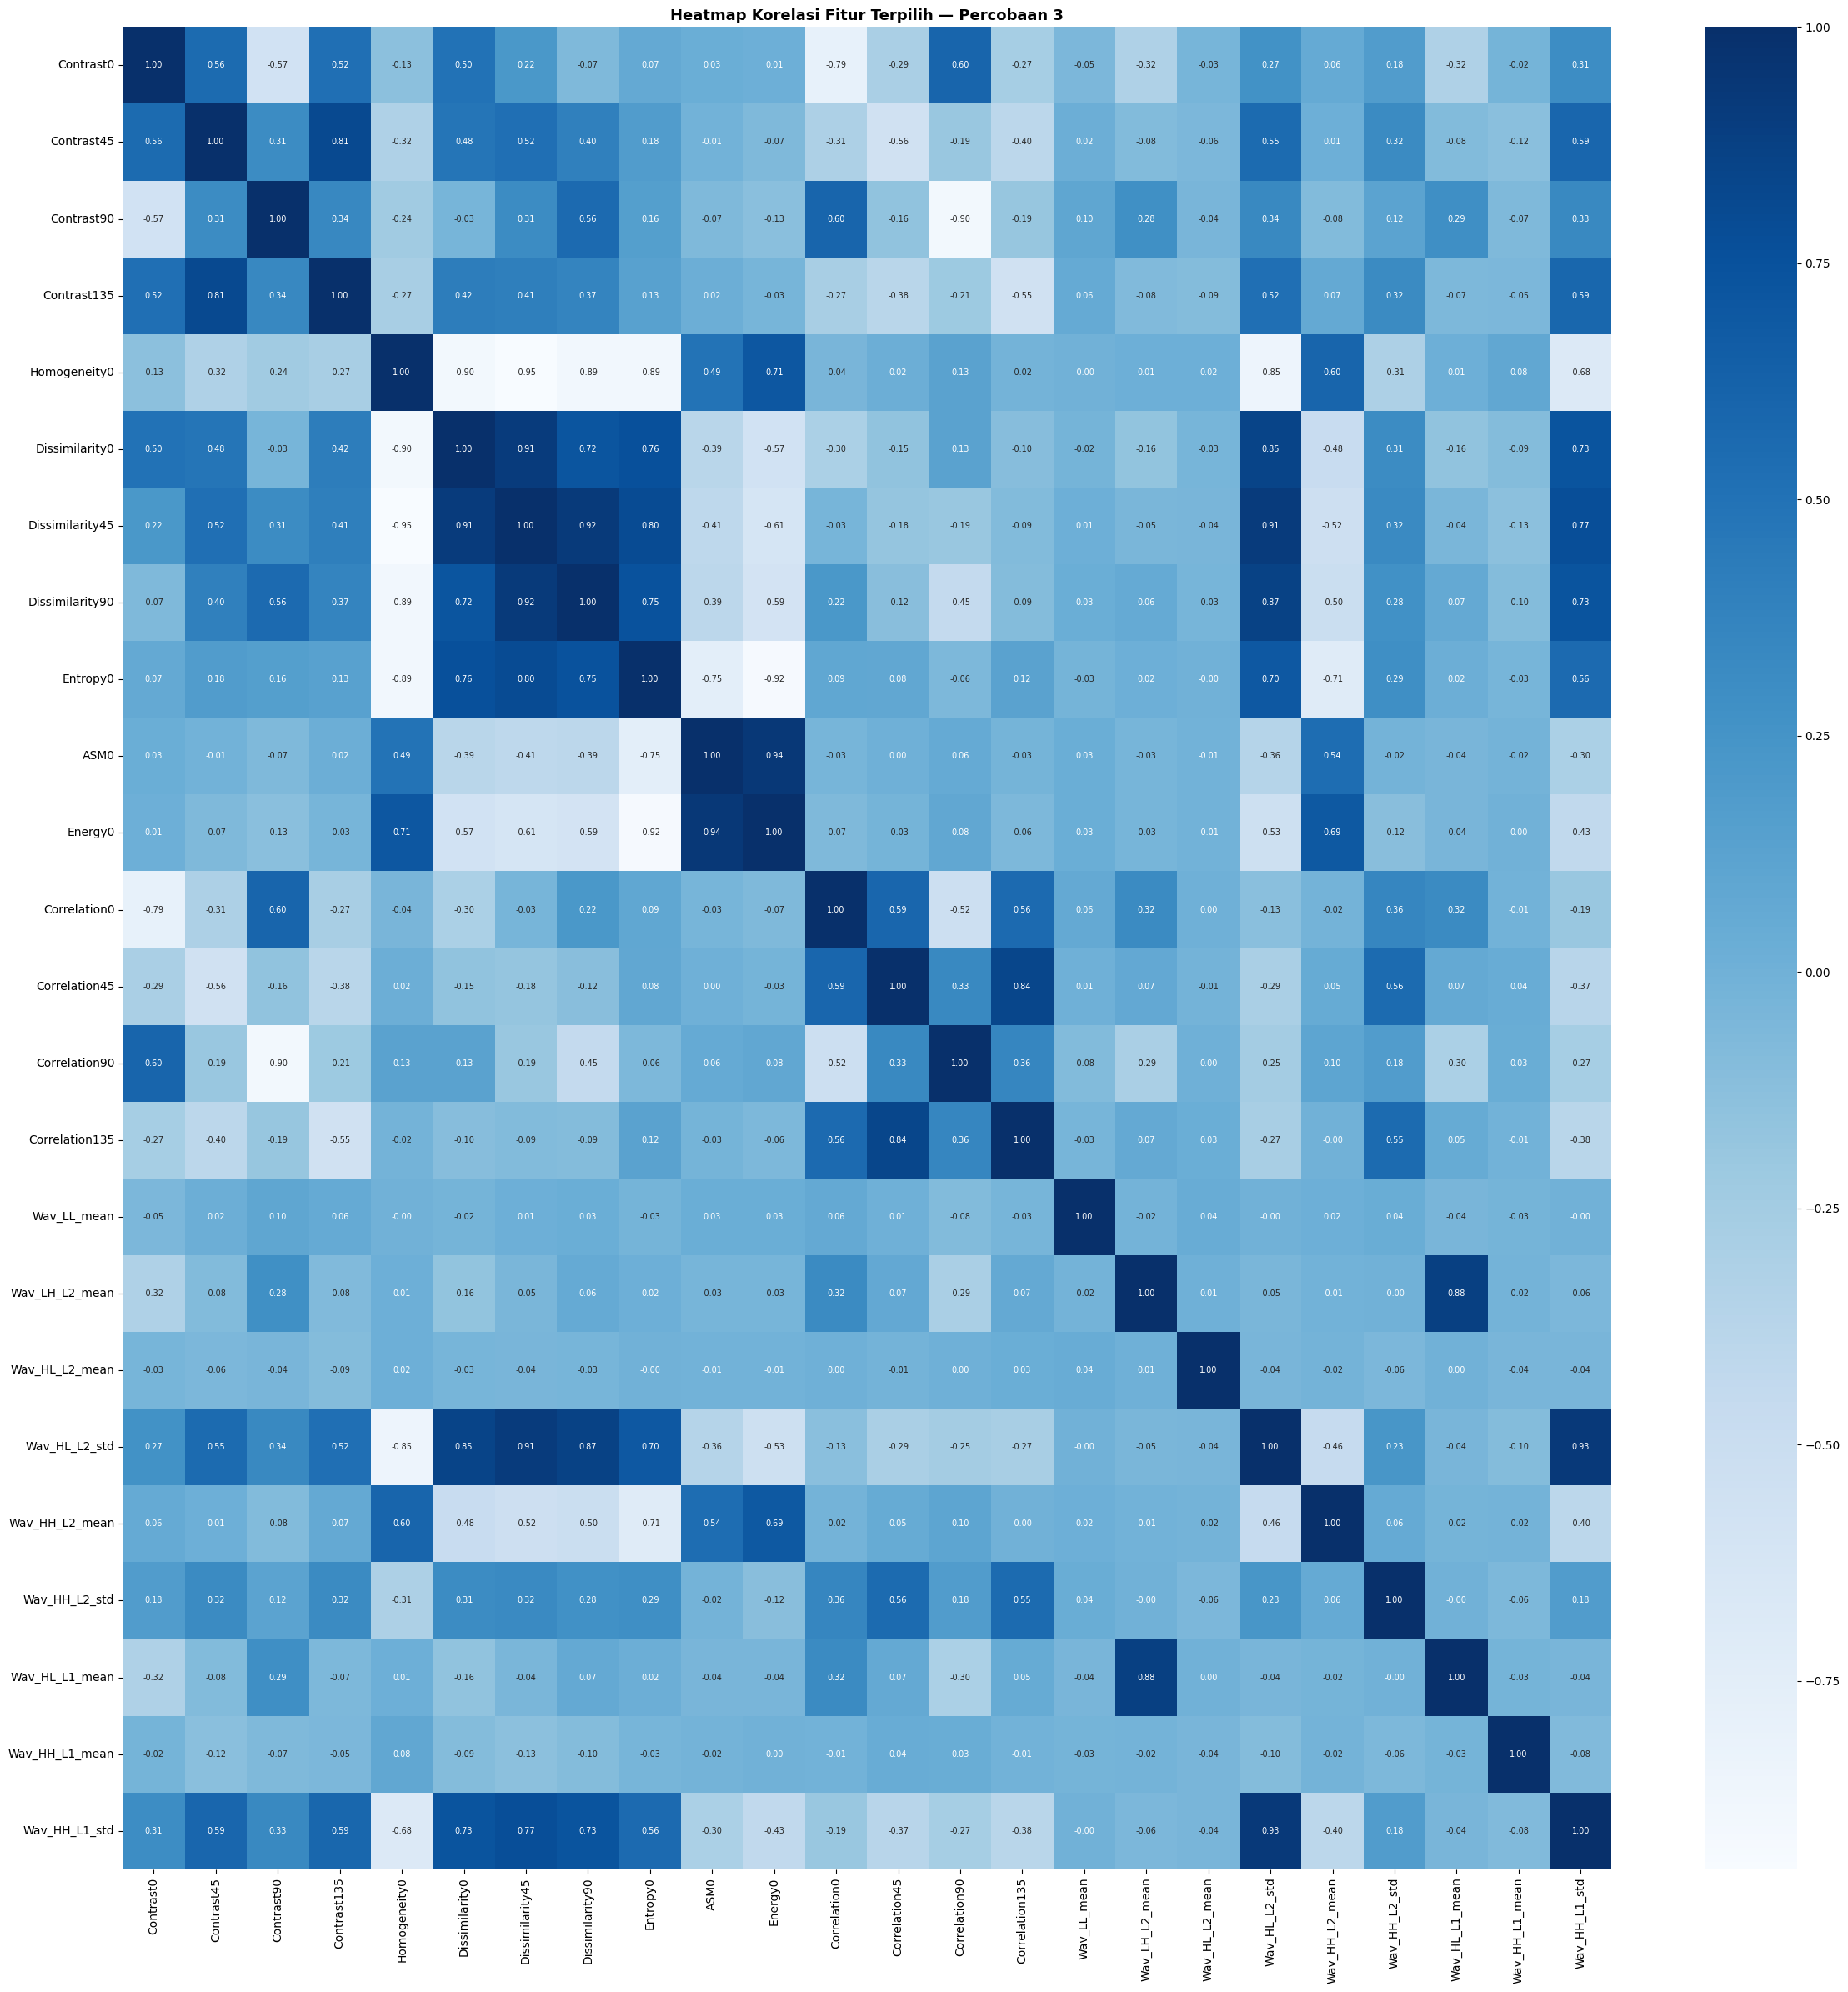

In [144]:
plt.figure(figsize=(max(12, x_new.shape[1]), max(10, x_new.shape[1])))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f",
            annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Terpilih — Percobaan 3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Normalisasi Fitur (Z-Score Standardization)

In [145]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)

train_mean = X_train.mean()
train_std  = X_train.std()

# Hindari pembagian dengan nol
train_std = train_std.replace(0, 1)

X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print("Normalisasi Z-Score selesai!")
print(f"   X_train setelah normalisasi: mean ≈ {X_train_norm.mean().mean():.4f}, std ≈ {X_train_norm.std().mean():.4f}")
print(f"   X_test  setelah normalisasi: mean ≈ {X_test_norm.mean().mean():.4f}")

Normalisasi Z-Score selesai!
   X_train setelah normalisasi: mean ≈ 0.0000, std ≈ 1.0000
   X_test  setelah normalisasi: mean ≈ -0.0172


## 11. Pemodelan & Klasifikasi

In [146]:
def generateClassificationReport(y_true, y_pred, set_name=""):
    print(f"\n{'='*55}")
    print(f"  {set_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred))
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

# Definisi model
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

print("Model berhasil didefinisikan!")
print("   - Random Forest  : n_estimators=100")
print("   - SVM            : kernel=RBF, C=1.0")
print("   - KNN            : n_neighbors=5")

Model berhasil didefinisikan!
   - Random Forest  : n_estimators=100
   - SVM            : kernel=RBF, C=1.0
   - KNN            : n_neighbors=5


In [147]:
print("\n RANDOM FOREST CLASSIFIER")
print("="*55)

rf.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_rf_train = rf.predict(X_train_norm)
rf_train_acc, rf_train_prec, rf_train_rec, rf_train_f1 = generateClassificationReport(
    y_train, y_pred_rf_train, "RF — Training Set")

print("\n---------- Testing Set ----------")
y_pred_rf_test = rf.predict(X_test_norm)
rf_test_acc, rf_test_prec, rf_test_rec, rf_test_f1 = generateClassificationReport(
    y_test, y_pred_rf_test, "RF — Testing Set")


 RANDOM FOREST CLASSIFIER

---------- Training Set ----------

  RF — Training Set
              precision    recall  f1-score   support

       blast       1.00      1.00      1.00       256
      blight       1.00      1.00      1.00       256
      tungro       1.00      1.00      1.00       256

    accuracy                           1.00       768
   macro avg       1.00      1.00      1.00       768
weighted avg       1.00      1.00      1.00       768

  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

---------- Testing Set ----------

  RF — Testing Set
              precision    recall  f1-score   support

       blast       0.97      0.97      0.97        64
      blight       0.96      1.00      0.98        64
      tungro       0.97      0.92      0.94        64

    accuracy                           0.96       192
   macro avg       0.96      0.96      0.96       192
weighted avg       0.96      0.96      0.96       192

  Accuracy  : 0

In [148]:
print("\n  SVM CLASSIFIER")
print("="*55)

svm.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_svm_train = svm.predict(X_train_norm)
svm_train_acc, svm_train_prec, svm_train_rec, svm_train_f1 = generateClassificationReport(
    y_train, y_pred_svm_train, "SVM — Training Set")

print("\n---------- Testing Set ----------")
y_pred_svm_test = svm.predict(X_test_norm)
svm_test_acc, svm_test_prec, svm_test_rec, svm_test_f1 = generateClassificationReport(
    y_test, y_pred_svm_test, "SVM — Testing Set")


  SVM CLASSIFIER

---------- Training Set ----------

  SVM — Training Set
              precision    recall  f1-score   support

       blast       0.86      0.88      0.87       256
      blight       0.92      0.96      0.94       256
      tungro       0.85      0.80      0.82       256

    accuracy                           0.88       768
   macro avg       0.88      0.88      0.88       768
weighted avg       0.88      0.88      0.88       768

  Accuracy  : 0.8789
  Precision : 0.8778
  Recall    : 0.8789
  F1-Score  : 0.8779

---------- Testing Set ----------

  SVM — Testing Set
              precision    recall  f1-score   support

       blast       0.84      0.77      0.80        64
      blight       0.90      0.95      0.92        64
      tungro       0.76      0.78      0.77        64

    accuracy                           0.83       192
   macro avg       0.83      0.83      0.83       192
weighted avg       0.83      0.83      0.83       192

  Accuracy  : 0.8333
 

In [149]:
print("\n KNN CLASSIFIER")
print("="*55)

knn.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_knn_train = knn.predict(X_train_norm)
knn_train_acc, knn_train_prec, knn_train_rec, knn_train_f1 = generateClassificationReport(
    y_train, y_pred_knn_train, "KNN — Training Set")

print("\n---------- Testing Set ----------")
y_pred_knn_test = knn.predict(X_test_norm)
knn_test_acc, knn_test_prec, knn_test_rec, knn_test_f1 = generateClassificationReport(
    y_test, y_pred_knn_test, "KNN — Testing Set")


 KNN CLASSIFIER

---------- Training Set ----------

  KNN — Training Set
              precision    recall  f1-score   support

       blast       0.81      0.93      0.86       256
      blight       0.89      0.96      0.93       256
      tungro       0.89      0.69      0.78       256

    accuracy                           0.86       768
   macro avg       0.86      0.86      0.86       768
weighted avg       0.86      0.86      0.86       768

  Accuracy  : 0.8607
  Precision : 0.8650
  Recall    : 0.8607
  F1-Score  : 0.8567

---------- Testing Set ----------

  KNN — Testing Set
              precision    recall  f1-score   support

       blast       0.77      0.80      0.78        64
      blight       0.88      0.95      0.92        64
      tungro       0.77      0.69      0.73        64

    accuracy                           0.81       192
   macro avg       0.81      0.81      0.81       192
weighted avg       0.81      0.81      0.81       192

  Accuracy  : 0.8125
  

## 12. Evaluasi — Confusion Matrix

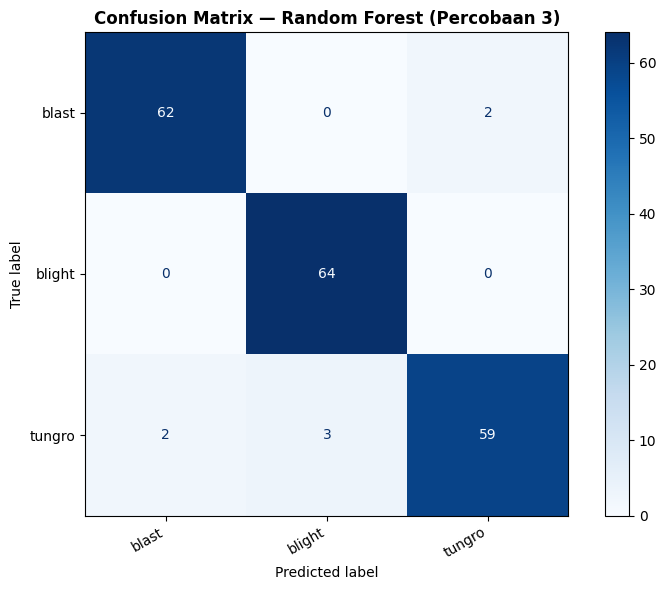

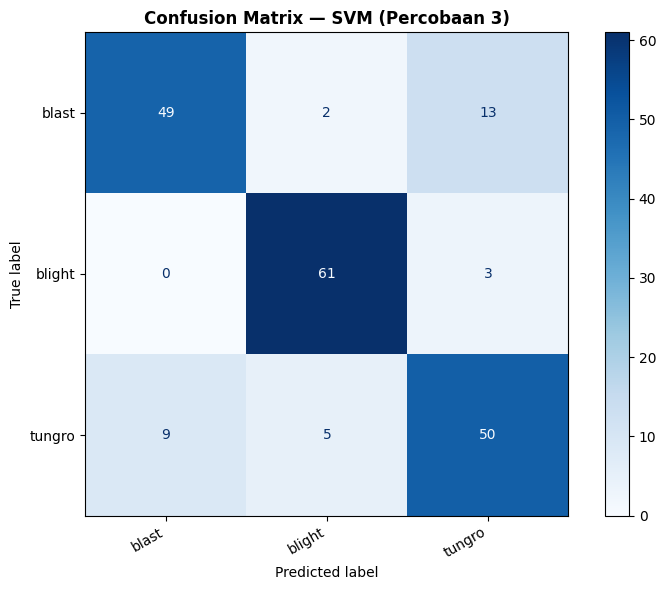

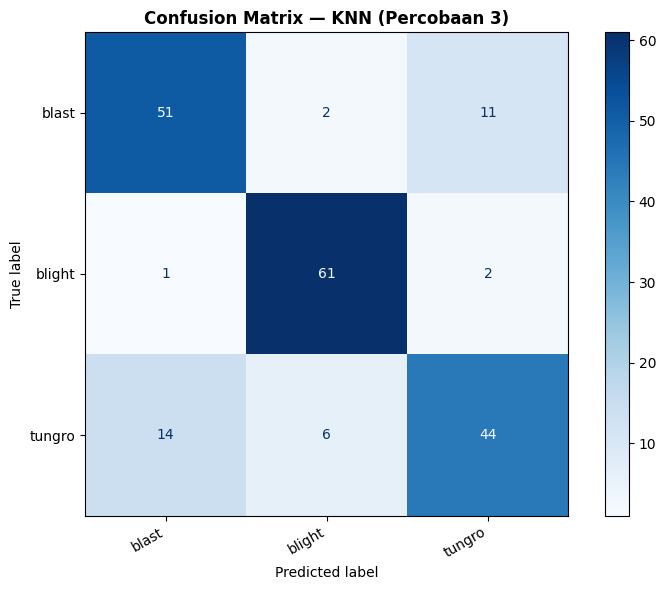

In [150]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf_test,  "Confusion Matrix — Random Forest (Percobaan 3)")
plot_confusion_matrix(y_test, y_pred_svm_test, "Confusion Matrix — SVM (Percobaan 3)")
plot_confusion_matrix(y_test, y_pred_knn_test, "Confusion Matrix — KNN (Percobaan 3)")

## 13. Ringkasan Hasil Percobaan 3

In [151]:
hasil_summary = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train' : [rf_train_acc,  svm_train_acc,  knn_train_acc],
    'Accuracy_Test'  : [rf_test_acc,   svm_test_acc,   knn_test_acc],
    'Precision_Test' : [rf_test_prec,  svm_test_prec,  knn_test_prec],
    'Recall_Test'    : [rf_test_rec,   svm_test_rec,   knn_test_rec],
    'F1_Score_Test'  : [rf_test_f1,    svm_test_f1,    knn_test_f1],
})

print(hasil_summary.to_string(index=False))

hasil_summary.to_csv('hasil_percobaan3.csv', index=False)

        Model  Accuracy_Train  Accuracy_Test  Precision_Test  Recall_Test  F1_Score_Test
Random Forest        1.000000       0.963542        0.963729     0.963542       0.963283
          SVM        0.878906       0.833333        0.833154     0.833333       0.832251
          KNN        0.860677       0.812500        0.809572     0.812500       0.809727


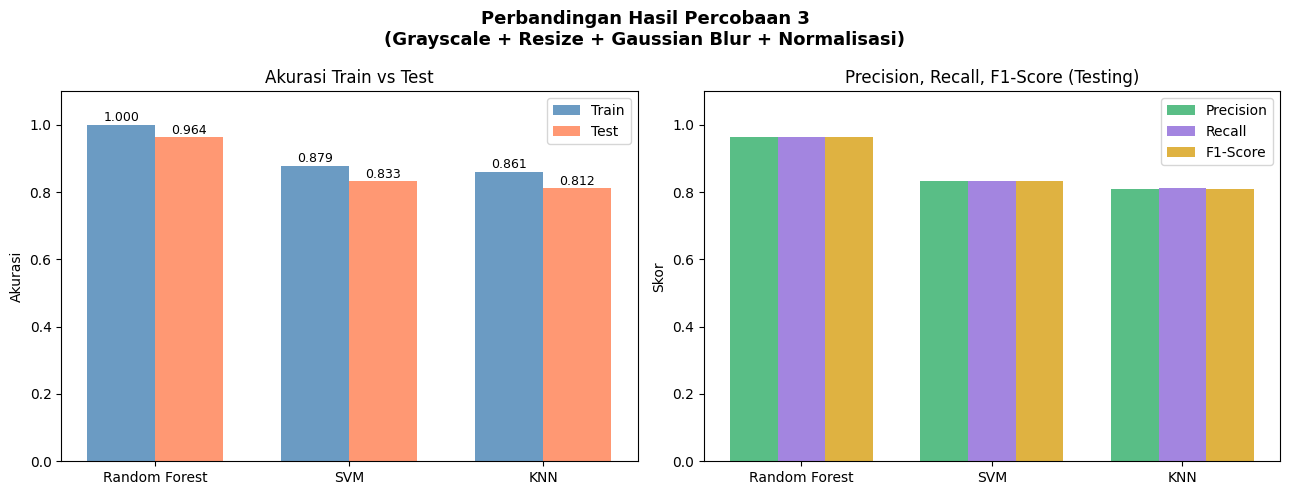

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Hasil Percobaan 3\n(Grayscale + Resize + Gaussian Blur + Normalisasi)',
             fontsize=13, fontweight='bold')

models = hasil_summary['Model']
x = np.arange(len(models))
width = 0.35

# Grafik Akurasi Train vs Test
axes[0].bar(x - width/2, hasil_summary['Accuracy_Train'], width, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, hasil_summary['Accuracy_Test'],  width, label='Test',  color='coral',     alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Akurasi')
axes[0].set_title('Akurasi Train vs Test')
axes[0].legend()
for xi, (tr, te) in enumerate(zip(hasil_summary['Accuracy_Train'], hasil_summary['Accuracy_Test'])):
    axes[0].text(xi - width/2, tr + 0.01, f"{tr:.3f}", ha='center', fontsize=9)
    axes[0].text(xi + width/2, te + 0.01, f"{te:.3f}", ha='center', fontsize=9)

# Grafik Precision, Recall, F1
w = 0.25
axes[1].bar(x - w, hasil_summary['Precision_Test'], w, label='Precision', color='mediumseagreen', alpha=0.85)
axes[1].bar(x,     hasil_summary['Recall_Test'],    w, label='Recall',    color='mediumpurple',   alpha=0.85)
axes[1].bar(x + w, hasil_summary['F1_Score_Test'],  w, label='F1-Score',  color='goldenrod',      alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Skor')
axes[1].set_title('Precision, Recall, F1-Score (Testing)')
axes[1].legend()

plt.tight_layout()
plt.show()